aSeqDIP Denoising: 100%|██████████| 2000/2000 [49:35<00:00,  1.49s/epoch, loss=0.000439]


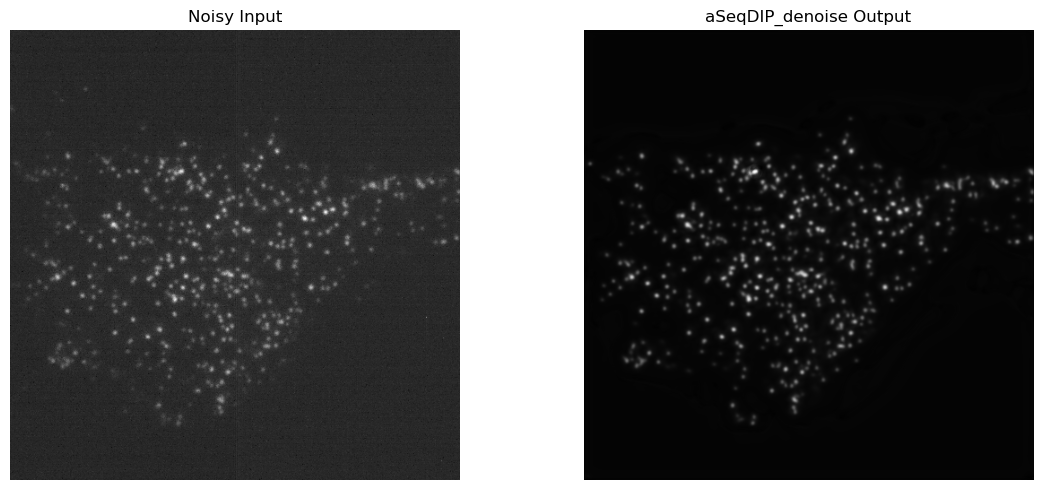

In [3]:
# -*- coding: utf-8 -*-
import os
import sys
sys.path.append('.')
sys.path.append('./Tools')

import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

from Tools import load_16bit_tiff, save_16bit_tiff, np_to_torch
from Tools import init_weights
from Tools import compare_psnr, compare_ssim
from unet import UNet

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype = torch.cuda.FloatTensor if torch.cuda.is_available() else torch.FloatTensor

# ==================== Parameters ====================
base_path = r'./image/aSeqDIPdenoise'
fname_noisy = os.path.join(base_path, 'CCPsRaw.tiff')
fname_gt = os.path.join(base_path, 'CCPsgt.tiff')   # Uncomment if GT exists

num_epochs = 2000
inner_iterations = 10
learning_rate = 1e-4

# ==================== Load images ====================
img_noisy_np = load_16bit_tiff(fname_noisy)
if len(img_noisy_np.shape) == 2:
    img_noisy_np = img_noisy_np[np.newaxis, :, :]
img_noisy_torch = np_to_torch(img_noisy_np).type(dtype)

# Check GT existence safely
if 'fname_gt' in locals() and os.path.exists(fname_gt):
    img_gt_np = load_16bit_tiff(fname_gt)
    if len(img_gt_np.shape) == 2:
        img_gt_np = img_gt_np[np.newaxis, :, :]
    img_gt_torch = np_to_torch(img_gt_np).type(dtype)
    has_gt = True
else:
    has_gt = False

# ==================== Network & optimizer ====================
net = UNet(n_channels=1, n_classes=1).to(device)
init_weights(net, init_type='normal', init_gain=0.02)
optimizer = optim.Adam(net.parameters(), lr=learning_rate)

net_input = img_noisy_torch.clone()
mse = torch.nn.MSELoss().type(dtype)

# ==================== Training loop ====================
best_combined_score = -1
best_combined_img = None
best_epoch = 0
x=800
output_x = None

epoch_iterator = tqdm(range(num_epochs), desc='aSeqDIP Denoising', unit='epoch')
for epoch in epoch_iterator:
    for _ in range(inner_iterations):
        optimizer.zero_grad()
        out = net(net_input)
        loss_data = mse(out, img_noisy_torch)
        loss_reg = mse(net_input, out)
        total_loss = loss_data + loss_reg
        total_loss.backward()
        optimizer.step()
    with torch.no_grad():
        net_input = out.detach().clone()

    if epoch == x:
        output_x = out.detach().cpu().numpy()[0, 0].copy()

    if has_gt and (epoch % 10 == 0 or epoch == num_epochs - 1):
        current_out_np = out.detach().cpu().numpy()[0, 0]
        current_gt_np = img_gt_torch.cpu().numpy()[0, 0]
        psnr_val = compare_psnr(current_gt_np, current_out_np)
        ssim_val = compare_ssim(current_gt_np, current_out_np)
        combined = (psnr_val / 50) + ssim_val
        if combined > best_combined_score:
            best_combined_score = combined
            best_combined_img = current_out_np.copy()
            best_epoch = epoch
            epoch_iterator.set_postfix(loss=total_loss.item())

# ==================== Display and save ====================
noisy_display = img_noisy_np[0]

if has_gt and best_combined_img is not None:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(noisy_display, cmap='gray')
    plt.axis('off')
    plt.title('Noisy Input')
    plt.subplot(1, 2, 2)
    plt.imshow(best_combined_img, cmap='gray')
    plt.axis('off')
    plt.title(f'aSeqDIP_denoise Output')
    plt.tight_layout()
    plt.show()
else:
    if output_x is None:
        output_x = net_input.cpu().numpy()[0, 0]
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(noisy_display, cmap='gray')
    plt.axis('off')
    plt.title('Noisy Input')
    plt.subplot(1, 2, 2)
    plt.imshow(output_x, cmap='gray')
    plt.axis('off')
    plt.title(f'aSeqDIP_denoise Output')
    plt.tight_layout()
    plt.show()